In [1]:
#data collection
import pandas as pd
df=pd.read_csv("Housing.csv")
print(df.head())

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


In [2]:
#data exploration&clenaing
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
None
              price          area    bedrooms   bathrooms     stories  \
count  5.450000e+02    545.000000  545.000000  545.000000  545.000000   
mea

In [5]:
#missing values
print(df.isnull().sum())
df=pd.get_dummies(df,drop_first=True)

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [6]:
#3.featuresselction
x=df.drop("price",axis=1)
y=df["price"]

In [8]:
#4.data spliting
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42
)

In [10]:
#5.model training
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [11]:
#6.prediction
y_pred=model.predict(x_test)

In [13]:
#7.model evalutaion
from sklearn.metrics import mean_squared_error,r2_score

mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)

print("mean squared error:",mse)
print("r2 score:",r2)

mean squared error: 1754318687330.663
r2 score: 0.6529242642153186


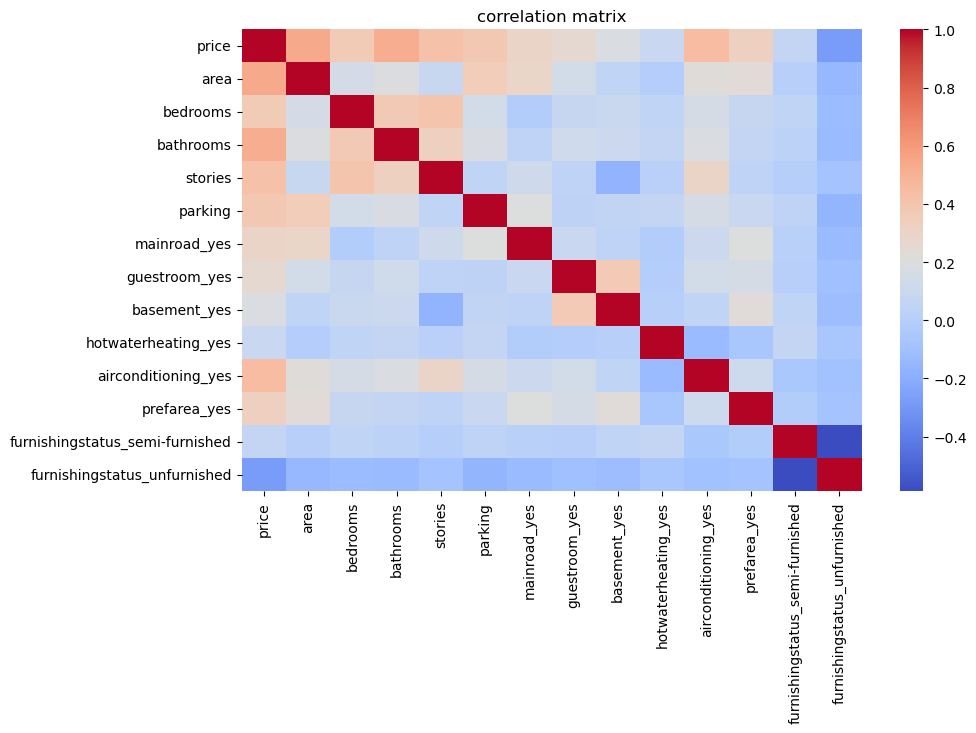

In [14]:
#8.visualiation
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(),cmap="coolwarm")
plt.title("correlation matrix")
plt.show()

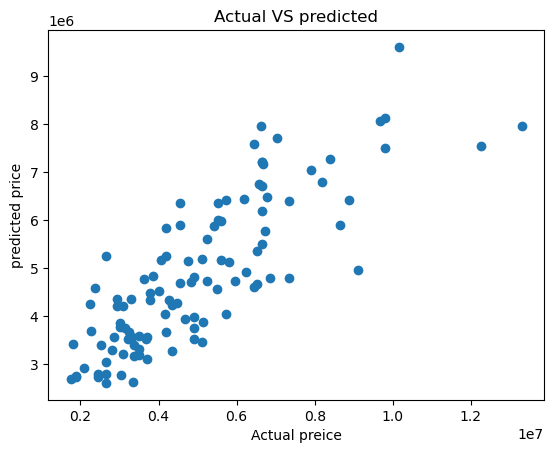

In [15]:
#actualVSpredicted
plt.scatter(y_test,y_pred)
plt.xlabel("Actual preice")
plt.ylabel("predicted price")
plt.title("Actual VS predicted")
plt.show()

In [17]:
#extra challenge(feature importance)
importance=pd.Series(model.coef_,index=x.columns)
print(importance.sort_values(ascending=False))

bathrooms                          1.094445e+06
airconditioning_yes                7.914267e+05
hotwaterheating_yes                6.846499e+05
prefarea_yes                       6.298906e+05
stories                            4.074766e+05
basement_yes                       3.902512e+05
mainroad_yes                       3.679199e+05
guestroom_yes                      2.316100e+05
parking                            2.248419e+05
bedrooms                           7.677870e+04
area                               2.359688e+02
furnishingstatus_semi-furnished   -1.268818e+05
furnishingstatus_unfurnished      -4.136451e+05
dtype: float64
